In [31]:
import pypsa
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
import pandas as pd
import os

In [32]:
TITLE_SIZE = 20

In [33]:
simpl = 182
n = pypsa.Network(f"/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/resources/CH2/tamu/ID/proactive/texas/elec_s{simpl}.nc")

INFO:pypsa.io:Imported network elec_s182.nc has buses, carriers, generators, lines, loads, storage_units


In [23]:
nb = pypsa.Network("/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/resources/CH2/tamu/ID/proactive/texas/elec_base_network.nc")

INFO:pypsa.io:Imported network elec_base_network.nc has buses, lines, line_types, transformers


In [35]:
regions_path = os.path.join(
    f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/resources/CH2/tamu/ID/proactive/texas/Geospatial/regions_offshore_s{simpl}.geojson'
)
regions_offshore = gpd.read_file(regions_path)

regions_onshore = gpd.read_file(
    f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/resources/CH2/tamu/ID/proactive/texas/Geospatial/regions_onshore_s{simpl}.geojson'
)

In [36]:
regions_onshore

,name,geometry
0,p600 0,"POLYGON ((-101.68867 32.50439, -101.70466 32.5..."
1,p610 0,"POLYGON ((-101.04074 30.87621, -101.49547 30.9..."
2,p610 1,"POLYGON ((-100.40111 29.08747, -100.59973 29.0..."
3,p610 2,"POLYGON ((-102.56849 29.76271, -102.57125 29.7..."
4,p620 0,"POLYGON ((-102.10909 31.69527, -102.07519 31.7..."
...,...,...
174,p670 5,"POLYGON ((-95.51228 28.83095, -95.57264 28.835..."
175,p670 6,"POLYGON ((-95.73571 29.56554, -95.75866 29.549..."
176,p670 7,"POLYGON ((-95.69288 29.94681, -95.74893 30.015..."
177,p670 8,"POLYGON ((-94.94233 29.72794, -94.97598 29.692..."


In [37]:
def plot_capacity_map(
    n: pypsa.Network,
    bus_values: pd.DataFrame,
    line_values: pd.DataFrame,
    link_values: pd.DataFrame,
    regions: gpd.GeoDataFrame,
    ax: plt.axes,
    bus_scale=1,
    line_scale=1,
    title=None,
    flow=None,
    line_colors="teal",
    link_colors="green",
    line_cmap="viridis",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
) -> plt.axes:
    """Generic network plotting function for capacity pie charts at each node."""
    line_width = line_values / line_scale
    link_width = link_values / line_scale

    with plt.rc_context({"patch.linewidth": 0.1}):
        n.plot(
            bus_sizes=bus_values / bus_scale,
            bus_colors=n.carriers.color,
            bus_alpha=0.7,
            line_widths=line_width,
            link_widths=0 if link_width.empty else link_width,
            line_colors=line_colors,
            link_colors=link_colors,
            ax=ax,
            margin=0.2,
            color_geomap=True,
            flow=flow,
            line_cmap=line_cmap,
            line_norm=line_norm,
            line_alpha=line_alpha,
            bus_split_circles=bus_split_circles,
        )

    # onshore regions
    regions.boundary.plot(
        ax=ax,
        facecolor="gainsboro",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=1.2,
    )
    ax.set_extent(regions.total_bounds[[0, 2, 1, 3]])

    ax.set_title(title or "Capacity (MW)", fontsize=TITLE_SIZE, pad=20)

    return ax


def plot_network_capacity(
    n: pypsa.Network,
    ax: plt.axes,
    regions: gpd.GeoDataFrame,
    plot_type: str = "base",
    bus_scale: float = 1e3,
    line_scale: float = 1e6,
    line_colors: str ="teal",
    link_colors: str="green",
    line_alpha: float = 0.5,
) -> plt.axes:
    """Plot network capacity for buses, lines, and links.".
    
    Options for plot_type:
    - base: Base network capacities
    - opt: Optimal network capacities
    - new: New network capacities
    """
    groupers = n.statistics.groupers

    if plot_type == "base":
        bus_groups = n.statistics.installed_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_groups = bus_groups[bus_groups.index.get_level_values('component') != 'Line']
        bus_groups = bus_groups.droplevel(0)
        bus_values= bus_groups[n.investment_periods[0]]

        line_values = n.lines.s_nom
        link_values = n.links[n.links.carrier == "AC"].p_nom.replace(to_replace={pd.NA: 0})
        title = "Base Network Capacities"
    
    elif plot_type == "opt":
        bus_groups = n.statistics.optimal_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_groups = bus_groups[bus_groups.index.get_level_values('component') != 'Line']
        bus_groups = bus_groups.droplevel(0)
        bus_values= bus_groups[n.investment_periods[0]]

        line_values = n.lines.s_nom_opt
        link_values = n.links[n.links.carrier == "AC"].p_nom_opt.replace(to_replace={pd.NA: 0})
        title = "Optimal Network Capacities"
    
    elif plot_type == "new":
        bus_pnom = n.statistics.installed_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_pnom = bus_pnom[bus_pnom.index.get_level_values('component') != 'Line']
        bus_pnom = bus_pnom.droplevel(0)


        bus_pnom_opt = n.statistics.optimal_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_pnom_opt = bus_pnom_opt[bus_pnom_opt.index.get_level_values('component') != 'Line']
        bus_pnom_opt = bus_pnom_opt.droplevel(0)

        bus_values = bus_pnom_opt - bus_pnom
        bus_values = bus_values[(bus_values > 0)]
        bus_values= bus_values[n.investment_periods[0]]

        
        line_values = n.lines.s_nom_opt - n.lines.s_nom
        link_pnom = n.links[n.links.carrier == "AC"].p_nom
        link_pnom_opt = n.links[n.links.carrier == "AC"].p_nom_opt
        link_values = link_pnom_opt - link_pnom
        link_values = link_values.replace(to_replace={pd.NA: 0})
        title = "New Network Capacities"
    
    else:
        raise ValueError(f"Unknown plot_type: {plot_type}")

    # Plot data
    plot_capacity_map(
        n=n,
        bus_values=bus_values,
        line_values=line_values,
        link_values=link_values,
        regions=regions,
        ax=ax,
        line_scale=line_scale,
        bus_scale=bus_scale,
        title=title,
        line_colors=line_colors,
        link_colors=link_colors,
        line_alpha=line_alpha,
    )
    return ax

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



<GeoAxes: title={'center': 'New Network Capacities'}>

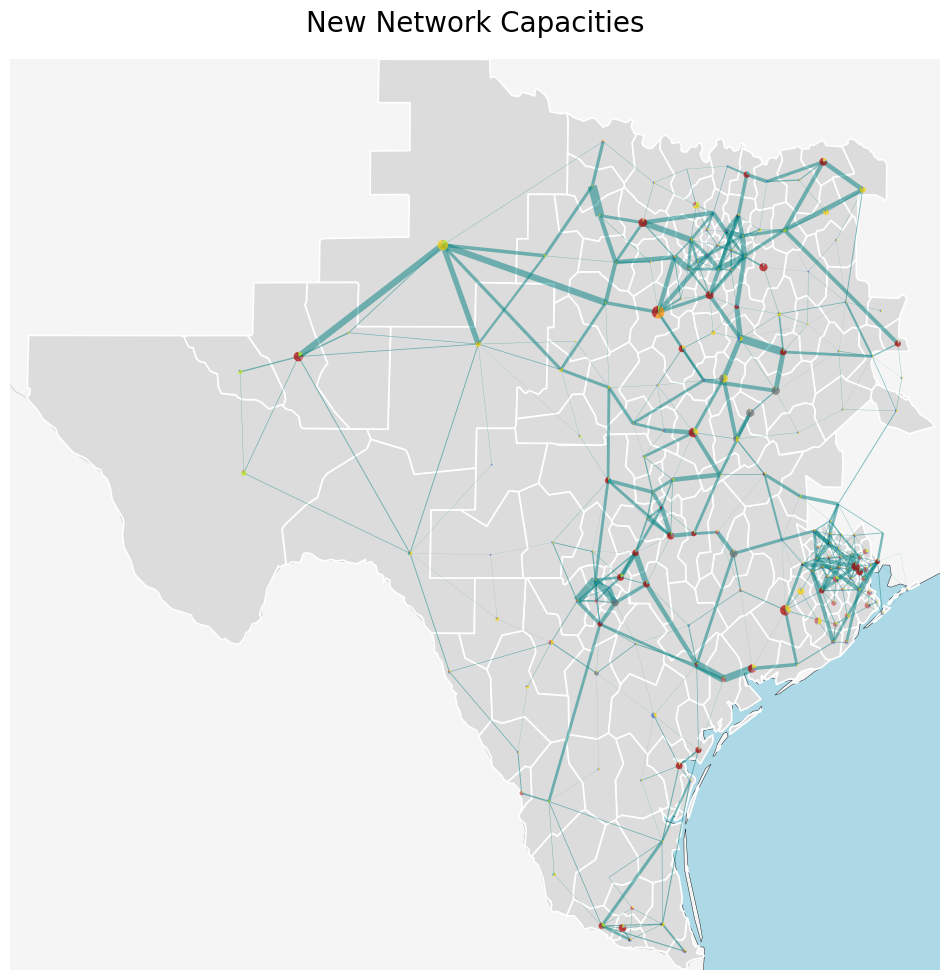

In [38]:
fig , axes = plt.subplots(1, 1, figsize=(12,12), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
# Plot data
bus_scale = 1e6
groupers = pypsa.statistics.groupers
n.generators.p_nom = n.generators.p_nom + 1e2
bus_capacities = n.statistics.installed_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
bus_capacities = bus_capacities.droplevel(0)
bus_capacities = bus_capacities[n.investment_periods[0]]

line_values = n.lines.s_nom
link_values = n.links[n.links.carrier == "AC"].p_nom.replace(to_replace={pd.NA: 0})
title = "Base Network Capacities"

plot_capacity_map(
    n=n,
    bus_values=bus_capacities,
    line_values=line_values,
    link_values=link_values,
    regions=regions_onshore,
    ax=axes,
    line_scale=1e3,
    bus_scale=bus_scale,
    title="New Network Capacities",
    line_colors="teal",
    link_colors="green",
    line_alpha=0.5,
)

In [39]:
n.lines.sort_values(by="s_nom", ascending=True).head(10)

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,interconnect,underwater_fraction,v_nom
Line,,,,,,,,,,,,,,,,,,,,,
75,p630 19,p630 28,,127.121683,21.173170,0.0,6.165162e-07,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230
56,p630 14,p630 42,,126.520089,21.065216,0.0,6.136603e-07,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230
58,p630 14,p630 66,,79.939230,13.309373,0.0,3.877096e-07,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230
234,p640 13,p640 6,,138.925866,24.317721,0.0,7.459373e-07,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230
243,p640 16,p640 7,,158.187716,26.352961,0.0,7.673671e-07,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230
219,p640 10,p640 3,,91.710873,16.056414,0.0,4.923391e-07,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230
221,p640 10,p650 11,,140.302057,58.407107,0.0,6.801079e-07,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230
222,p640 10,p670 24,,105.664155,18.500638,0.0,5.674507e-07,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230
20,p610 1,p650 9,,229.562385,40.200782,0.0,1.232690e-06,98.0,0.0,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Texas,0.0,230


In [40]:
n.explore()

INFO:pypsa.plot:Components rendered on the map: Bus, Line.
INFO:pypsa.plot:Components omitted as they are missing or not selected: Generator, Link, Load, StorageUnit, Transformer.


In [41]:
nb.explore()

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/plot.py:1386: UserWarning:

The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.

INFO:pypsa.plot:Components rendered on the map: Bus, Line, Transformer.
INFO:pypsa.plot:Components omitted as they are missing or not selected: Generator, Link, Load, StorageUnit.
